In [7]:
## Section 1: Data Preparation
## 1. Import & Setup

!pip install emoji -q

# Standard library
import re

# Data handling
import pandas as pd
import numpy as np

# Text processing
import emoji

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Print versions for reproducibility
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
print(f"emoji       {emoji.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"seaborn     {sns.__version__}")

pandas      2.2.3
numpy       2.2.3
emoji       2.14.1
matplotlib  3.10.0
seaborn     0.13.2


In [8]:
## 2. Load Data

df = pd.read_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/raw_comment_csv.csv')

print(f"Shape        : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
print()
print(df.head())

Shape        : (5706, 9)
Columns      : ['Comments_index', 'createTimeISO', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'replyCommentTotal', 'text', 'Len', 'videoWebUrl']

   Comments_index             createTimeISO  diggCount  likedByAuthor  \
0               1  2026-03-20T23:18:11.000Z        522          False   
1               2  2026-04-04T12:21:21.000Z          0          False   
2               3  2026-03-31T04:40:24.000Z          2          False   
3               4  2026-03-31T08:03:30.000Z          1          False   
4               5  2026-03-23T03:57:19.000Z       1162          False   

   pinnedByAuthor  replyCommentTotal  \
0           False                  6   
1           False                  0   
2           False                  1   
3           False                  6   
4           False                  3   

                                                text  Len  \
0                                  T-34 looking ship   17   
1  Truly, an interesti

In [11]:
## 3. Descriptive Statistics

print("=== diggCount ===")
print(df['diggCount'].describe().round(2))

print("\n=== Text Length (characters) ===")
print(df['Len'].describe().round(2))

=== diggCount ===
count       5706.00
mean        3940.73
std        27736.48
min            0.00
25%            7.00
50%           50.00
75%          507.00
max      1151659.00
Name: diggCount, dtype: float64

=== Text Length (characters) ===
count    5706.00
mean       74.85
std        89.61
min         2.00
25%        29.00
50%        49.00
75%        92.00
max      2153.00
Name: Len, dtype: float64


In [13]:
## 4. Filtering

def clean_text(text):
    text = str(text)

    # Step 1: Remove emoji
    text = emoji.replace_emoji(text, replace='')

    # Step 2: Remove [sticker] tags (case-insensitive)
    text = re.sub(r'\[sticker\]', '', text, flags=re.IGNORECASE)

    # Step 3: Remove @mentions
    text = re.sub(r'@\S+', '', text)
    
    # Strip extra whitespace
    text = text.strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
df['Len_clean'] = df['text_clean'].apply(len)

# Step 5: Remove comments with 2 or fewer characters
df_filtered = df[df['Len_clean'] > 2].reset_index(drop=True)
print(f"After cleaning & length filter (>2)     : {len(df_filtered)}")

# Step 6: Remove short comments with no engagement
df_filtered = df_filtered[
    (df_filtered['Len_clean'] > 10) |
    ((df_filtered['Len_clean'] <= 10) & (df_filtered['diggCount'] > 0))
].reset_index(drop=True)
print(f"After short + no engagement filter      : {len(df_filtered)}")

print(f"\nTotal removed : {len(df) - len(df_filtered)}")

After cleaning & length filter (>2)     : 5609
After short + no engagement filter      : 5589

Total removed : 117


In [15]:
##  5. Language Filtering

def is_latin_based(text):
    text = str(text)
    letters = [c for c in text if c.isalpha()]
    if len(letters) == 0:
        return True
    latin = [c for c in letters if ord(c) < 591]
    return (len(latin) / len(letters)) >= 0.8

df_filtered['is_latin'] = df_filtered['text_clean'].apply(is_latin_based)

df_english = df_filtered[df_filtered['is_latin']].reset_index(drop=True)
df_removed = df_filtered[~df_filtered['is_latin']].reset_index(drop=True)

print(f"After language filter : {len(df_english)}")
print(f"Removed               : {len(df_removed)}")
print(f"\n=== Sample of removed comments (n=10) ===")
print(df_removed[['text_clean', 'diggCount']].head(10).to_string())

After language filter : 5582
Removed               : 7

=== Sample of removed comments (n=10) ===
                                                       text_clean  diggCount
0                                                     تمثال امرأة          0
1  ....предки моего прадеда,деда...и мамули...ну и конечно мои...          0
2               It’s Архангельск not Archangelsk. Nope that helps         14
3                                            الله يرحمه و يغفر له         22
4                                                          Поклон          1
5                                                לא נשכח ולא נסלח       1524
6                                    Смотрю это как будто понимаю        120


In [23]:
## 6. Export Cleaned Data

df_clean = df_english.drop(columns=['is_latin', 'Len', 'text'])
df_clean = df_clean.rename(columns={'text_clean': 'text', 'Len_clean': 'Len'})

df_clean.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_clean.csv', index=False)

print(f"Exported : {len(df_clean)} comments")
print(f"Columns  : {df_clean.columns.tolist()}")

Exported : 5582 comments
Columns  : ['Comments_index', 'createTimeISO', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'replyCommentTotal', 'videoWebUrl', 'text', 'Len']


In [25]:
## 7. Extract Unique Video URLs

df_clean = pd.read_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_clean.csv')

urls = df_clean['videoWebUrl'].unique()
print(f"Unique videos: {len(urls)}")

with open('video_urls.txt', 'w') as f:
    for url in urls:
        f.write(url + '\n')

print("Saved → video_urls.txt")

Unique videos: 200
Saved → video_urls.txt


In [27]:
## 8. Merge Video Labels

df_labels = pd.read_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/video_labels.csv', sep=';')

df_clean = df_clean.merge(df_labels, left_on='videoWebUrl', right_on='url', how='left')
df_clean = df_clean.drop(columns=['url'])

# list comments can't pair their labels
missing_urls = df_clean[df_clean['content_type'].isna()]['videoWebUrl'].unique()
print(f"Missing video URLs: {len(missing_urls)}")
for url in missing_urls:
    print(url)

print(f"Shape after merge: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")
print(f"Missing labels: {df_clean['content_type'].isna().sum()}")


Missing video URLs: 0
Shape after merge: (5582, 11)
Columns: ['Comments_index', 'createTimeISO', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'replyCommentTotal', 'videoWebUrl', 'text', 'Len', 'topic', 'content_type']
Missing labels: 0


In [29]:
## 9. Export Final Dataset

df_clean.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_final.csv', index=False)

print(f"Exported: {len(df_clean)} comments")
print(f"Columns: {df_clean.columns.tolist()}")
print(f"\nContent type distribution:")
print(df_clean['content_type'].value_counts())

Exported: 5582 comments
Columns: ['Comments_index', 'createTimeISO', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'replyCommentTotal', 'videoWebUrl', 'text', 'Len', 'topic', 'content_type']

Content type distribution:
content_type
historical_detail    2007
historical_event     1538
historical_figure    1142
historical_object     642
mystery               253
Name: count, dtype: int64


In [31]:
## 10. Random Sampling for Annotation

df_sample = df_clean.sample(n=250, random_state=42)

df_annotate = df_sample.iloc[0:200]
df_backup = df_sample.iloc[200:250]
df_remaining = df_clean.drop(df_sample.index)  

df_annotate.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_annotate.csv', index=False)
df_backup.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_backup.csv', index=False)
df_remaining.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_remaining.csv', index=False)

print(f"Annotate set  : {len(df_annotate)}")
print(f"Backup set    : {len(df_backup)}")
print(f"Remaining set : {len(df_remaining)}")

Annotate set  : 200
Backup set    : 50
Remaining set : 5332


In [3]:
## Section 2: Model Training Preparation

## 11. Install necessary packages
# install setfit
import sys 
!{sys.executable} -m pip install setfit

  Using cached setfit-1.1.3-py3-none-any.whl.metadata (12 kB)
  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached sentence_transformers-5.4.0-py3-none-any.whl.metadata (17 kB)
  Using cached transformers-5.5.3-py3-none-any.whl.metadata (32 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached huggingface_hub-1.10.1-py3-none-any.whl.metadata (14 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached setfit-1.1.3-py3-none-any.whl (75 kB)
Using cached datasets-4.8.4-py3-none-any.whl (526 kB)
Using cached evaluate-0.4.6-py3-none-any.whl (84 kB)
U

In [9]:
import sys
!{sys.executable} -m pip install transformers==4.41.0 -q

In [39]:
import sys
!{sys.executable} -m pip install sentence-transformers==3.3.0 -q

In [1]:
from setfit import SetFitModel, Trainer, TrainingArguments
from datasets import Dataset
import torch

print("SetFit imported successfully!")
print(f"MPS available: {torch.backends.mps.is_available()}")

/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SetFit imported successfully!
MPS available: True


In [3]:
## 12. Load Data

import pandas as pd

df_train = pd.read_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_annotate_final.csv', sep=';')
df_predict = pd.read_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_remaining_final.csv', sep=';')

# Normalize labels
df_train['label'] = df_train['Heuristic Type'].str.lower().str.strip()

print(f"Training set: {len(df_train)} comments")
print(f"Prediction set: {len(df_predict)} comments")
print(f"\nLabel distribution:")
print(df_train['label'].value_counts())

Training set: 222 comments
Prediction set: 5310 comments

Label distribution:
label
involvement    106
prior           65
source          13
realism          9
machine          8
expectancy       8
persuasive       8
platform         5
Name: count, dtype: int64


In [5]:
## 13. Create Context Text

def create_context_text(row):
    return f"[VIDEO: {row['topic']} | TYPE: {row['content_type']}] {row['text']}"

df_train['text_input'] = df_train.apply(create_context_text, axis=1)
df_predict['text_input'] = df_predict.apply(create_context_text, axis=1)

print("Sample training text:")
print(df_train['text_input'].iloc[0])
print()
print("Sample prediction text:")
print(df_predict['text_input'].iloc[0])

Sample training text:
[VIDEO: Drug policy historical context opium wars Gaza | TYPE: historical_detail] And remember kids the next time that somebody tells you “the government wouldn’t do that” OH YES THEY WOULD.

Sample prediction text:
[VIDEO: CSS Virginia ironclad warship Civil War | TYPE: historical_object] T-34 looking ship


In [11]:
## Section 3: Model Training

##14. Train SetFit Model
from datasets import Dataset

label2id = {
    'involvement': 0,
    'prior': 1,
    'source': 2,
    'realism': 3,
    'expectancy': 4,
    'machine': 5,
    'persuasive': 6,
    'platform': 7,
}
id2label = {v: k for k, v in label2id.items()}

df_train['label_id'] = df_train['label'].map(label2id)

unmapped = df_train[df_train['label_id'].isna()]
if len(unmapped) > 0:
    print(f"WARNING: {len(unmapped)} unmapped labels:")
    print(unmapped['label'].value_counts())
else:
    print("All labels mapped successfully")

train_dataset = Dataset.from_dict({
    'text': df_train['text_input'].tolist(),
    'label': df_train['label_id'].tolist(),
})

# 强制使用MPS
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

model = SetFitModel.from_pretrained(
    "sentence-transformers/paraphrase-MiniLM-L6-v2",
    labels=list(label2id.keys()),
    device=device,
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=3,
    evaluation_strategy="no",
    save_strategy="no",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
)

trainer.train()
print("Training complete!")


All labels mapped successfully
Using device: mps


/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.
Map: 100%|██████████| 222/222 [00:00<00:00, 20573.03 examples/s]
***** Running training *****
  Num unique pairs = 33356
  Batch size = 16
  Num epochs = 3
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loade

Step,Training Loss
1,0.346900
50,0.310400
100,0.256700
150,0.244100
200,0.242700
250,0.230500
300,0.219800
350,0.205800
400,0.186600
450,0.158600


Training complete!


In [15]:
## 15. Classify 3000 Comments with Initial Model

import numpy as np

# Split remaining 5310 into 3000 (for semi-supervised expansion) and 2310 (for final classification and close reading)
df_expand = df_predict.sample(n=3000, random_state=42).reset_index(drop=True)
df_final = df_predict.drop(df_expand.index).reset_index(drop=True)

print(f"Expansion set: {len(df_expand)} comments")
print(f"Final classification set: {len(df_final)} comments")

# Get predictions and confidence scores
texts = df_expand['text_input'].tolist()
predictions = model.predict(texts)

# Get probabilities differently
proba_list = []
for text in texts:
    proba = model.predict_proba([text])
    proba_list.append(float(proba.max()))

df_expand['predicted_label'] = predictions
df_expand['confidence'] = proba_list

print(f"\nPredicted label distribution:")
print(df_expand['predicted_label'].value_counts())
print(f"\nConfidence score distribution:")
print(df_expand['confidence'].describe())

Expansion set: 3000 comments
Final classification set: 2310 comments

Predicted label distribution:
predicted_label
involvement    1758
prior           906
source          148
expectancy       70
persuasive       45
realism          40
platform         19
machine          14
Name: count, dtype: int64

Confidence score distribution:
count    3000.000000
mean        0.942272
std         0.143874
min         0.201470
25%         0.990750
50%         0.998829
75%         0.999344
max         0.999555
Name: confidence, dtype: float64


In [17]:
## 16. Filter High-Confidence Predictions

df_high_conf = df_expand[df_expand['confidence'] > 0.85]
print(f"High confidence (>0.85): {len(df_high_conf)} comments")
print(df_high_conf['predicted_label'].value_counts())

High confidence (>0.85): 2622 comments
predicted_label
involvement    1657
prior           831
source           66
realism          25
expectancy       23
persuasive        8
platform          7
machine           5
Name: count, dtype: int64


In [19]:
# 17. Sample up to 30 comments per label for manual verification
sample_per_label = []
for label in df_high_conf['predicted_label'].unique():
    label_df = df_high_conf[df_high_conf['predicted_label'] == label]
    n = min(30, len(label_df))
    sample_per_label.append(label_df.sample(n=n, random_state=42))

df_check = pd.concat(sample_per_label).reset_index(drop=True)
print(f"Manual check set: {len(df_check)} comments")
print(df_check['predicted_label'].value_counts())

# Export for manual verification
df_check.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_check.csv', index=False)
print("Saved to comments_check.csv")

Manual check set: 158 comments
predicted_label
prior          30
involvement    30
source         30
realism        25
expectancy     23
persuasive      8
platform        7
machine         5
Name: count, dtype: int64
Saved to comments_check.csv


In [21]:
## 17. Evaluate Model & Prepare Expanded Training Set

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# Load manually verified results
df_check = pd.read_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_check_final.csv', sep=';', on_bad_lines='skip')

# Normalize labels
df_check['Correct Label'] = df_check['Correct Label'].str.lower().str.strip()
df_check['Correct Label'] = df_check['Correct Label'].str.replace('invovement', 'involvement')

# Final label: if YES keep predicted, if NO use correct label
df_check['final_label'] = df_check.apply(
    lambda row: row['predicted_label'] if row['Manual Verification'] == 'YES'
    else row['Correct Label'], axis=1
)

# Calculate accuracy
y_true = df_check['final_label'].tolist()
y_pred = df_check['predicted_label'].tolist()

print("=== Model Evaluation on Manually Verified Sample ===")
print(f"Overall accuracy: {(df_check['Manual Verification'] == 'YES').sum()}/{len(df_check)} = {(df_check['Manual Verification'] == 'YES').mean():.1%}")
print()
print(classification_report(y_true, y_pred, zero_division=0))

=== Model Evaluation on Manually Verified Sample ===
Overall accuracy: 98/156 = 62.8%

              precision    recall  f1-score   support

  expectancy       0.43      0.91      0.59        11
 involvement       0.90      0.50      0.64        54
     machine       0.40      1.00      0.57         2
  persuasive       0.38      1.00      0.55         3
    platform       0.00      0.00      0.00         1
       prior       0.93      0.62      0.75        45
     realism       0.96      0.92      0.94        25
      source       0.21      0.40      0.27        15

    accuracy                           0.63       156
   macro avg       0.53      0.67      0.54       156
weighted avg       0.80      0.63      0.67       156



In [23]:
## 18a. Retrain Model with Expanded Training Set (all-MiniLM-L6-v2)

# Combine original annotated data with verified high-confidence predictions
df_train_original = df_train[['text_input', 'label']].copy()

df_train_expanded = df_check[['text_input', 'final_label']].copy()
df_train_expanded = df_train_expanded.rename(columns={'final_label': 'label'})

# Remove rows with missing labels
df_train_expanded = df_train_expanded.dropna(subset=['label'])

df_train_combined = pd.concat([df_train_original, df_train_expanded], ignore_index=True)

print(f"Original training set: {len(df_train_original)} comments")
print(f"Expanded training set: {len(df_train_expanded)} comments")
print(f"Combined training set: {len(df_train_combined)} comments")
print()
print("Combined label distribution:")
print(df_train_combined['label'].value_counts())

# Remap labels
df_train_combined['label_id'] = df_train_combined['label'].map(label2id)

# Check unmapped
unmapped = df_train_combined[df_train_combined['label_id'].isna()]
if len(unmapped) > 0:
    print(f"\nWARNING: {len(unmapped)} unmapped labels:")
    print(unmapped['label'].value_counts())

# Prepare dataset
train_dataset_expanded = Dataset.from_dict({
    'text': df_train_combined['text_input'].tolist(),
    'label': df_train_combined['label_id'].tolist(),
})

# Load fresh model
model2 = SetFitModel.from_pretrained(
    "sentence-transformers/paraphrase-MiniLM-L6-v2",
    labels=list(label2id.keys()),
    device=device,
)

# Train with expanded dataset
args2 = TrainingArguments(
    batch_size=16,
    num_epochs=3,
    evaluation_strategy="no",
    save_strategy="no",
)

trainer2 = Trainer(
    model=model2,
    args=args2,
    train_dataset=train_dataset_expanded,
)

trainer2.train()
print("Retraining complete!")

Original training set: 222 comments
Expanded training set: 156 comments
Combined training set: 378 comments

Combined label distribution:
label
involvement    160
prior          110
realism         34
source          28
expectancy      19
persuasive      11
machine         10
platform         6
Name: count, dtype: int64


/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.
Map: 100%|██████████| 378/378 [00:00<00:00, 21951.50 examples/s]
***** Running training *****
  Num unique pairs = 102626
  Batch size = 16
  Num epochs = 3
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(load

Step,Training Loss
1,0.406400
50,0.321100
100,0.285400
150,0.272000
200,0.255300
250,0.254300
300,0.245000
350,0.244300
400,0.238200
450,0.232900


Retraining complete!


In [35]:
## 19a. Classify Final 2310 Comments using retrained model MiniLM-L6-v2

# Classify final 2310 comments 
texts_final = df_final['text_input'].tolist()
predictions_final = model2.predict(texts_final)
df_final['predicted_label'] = predictions_final

# Add confidence scores
print("Adding confidence scores...")
proba_list_final = []
for text in texts_final:
    proba = model2.predict_proba([text])
    proba_list_final.append(float(proba.max()))

df_final['confidence'] = proba_list_final

print(f"Classification complete: {len(df_final)} comments")
print()
print("Predicted label distribution:")
print(df_final['predicted_label'].value_counts())
print()
print("Confidence distribution:")
print(df_final['confidence'].describe())
print()
print(f"Low confidence (<0.85): {(df_final['confidence'] < 0.85).sum()} comments")

# Save results
df_final.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_classified.csv', index=False)
print("Saved to comments_classified.csv")

Adding confidence scores...
Classification complete: 2310 comments

Predicted label distribution:
predicted_label
involvement    1341
prior           760
source           66
expectancy       60
persuasive       27
platform         25
realism          23
machine           8
Name: count, dtype: int64

Confidence distribution:
count    2310.000000
mean        0.979791
std         0.078574
min         0.339051
25%         0.999268
50%         0.999557
75%         0.999680
max         0.999702
Name: confidence, dtype: float64

Low confidence (<0.85): 108 comments
Saved to comments_classified.csv


In [36]:
## 18b. Retrain with all-mpnet-base-v2 (Higher Accuracy Model)

# Load fresh model with all-mpnet-base-v2
model3 = SetFitModel.from_pretrained(
    "sentence-transformers/all-mpnet-base-v2",
    labels=list(label2id.keys()),
    device=device,
)

# Training arguments
args3 = TrainingArguments(
    batch_size=16,
    num_epochs=3,
    evaluation_strategy="no",
    save_strategy="no",
)

# Train with same expanded dataset (378 comments)
trainer3 = Trainer(
    model=model3,
    args=args3,
    train_dataset=train_dataset_expanded,
)

trainer3.train()
print("Training complete with all-mpnet-base-v2!")

/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.
Map: 100%|██████████| 378/378 [00:00<00:00, 12091.39 examples/s]
***** Running training *****
  Num unique pairs = 102626
  Batch size = 16
  Num epochs = 3
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(load

Step,Training Loss
1,0.388000
50,0.313700
100,0.274600
150,0.264200
200,0.250300
250,0.240300
300,0.220000
350,0.207900
400,0.206700
450,0.197100


Training complete with all-mpnet-base-v2!


In [47]:
## 19b. Classify Final 2310 Comments  with all-mpnet-base-v2

# Classify 2310 comments
texts_final3 = df_final['text_input'].tolist()
predictions_final3 = model3.predict(texts_final3)

# Add confidence scores
proba_list3 = []
for text in texts_final3:
    proba = model3.predict_proba([text])
    proba_list3.append(float(proba.max()))

# Create clean output dataframe
df_final_mpnet = df_final[['Comments_index', 'createTimeISO', 'diggCount', 'likedByAuthor',
                            'pinnedByAuthor', 'replyCommentTotal', 'videoWebUrl', 'text',
                            'Len', 'topic', 'content_type', 'text_input']].copy()

df_final_mpnet['predicted_label'] = predictions_final3
df_final_mpnet['confidence'] = proba_list3

print("=== Model 3 (all-mpnet-base-v2) Classification Results ===")
print(df_final_mpnet['predicted_label'].value_counts())
print()
print("Confidence distribution:")
print(df_final_mpnet['confidence'].describe())
print()
print(f"Low confidence (<0.85): {(df_final_mpnet['confidence'] < 0.85).sum()} comments")

# Save
df_final_mpnet.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/comments_classified_mpnet.csv', index=False)
print("Saved to comments_classified_mpnet.csv")

Adding confidence scores...
=== Model 3 (all-mpnet-base-v2) Classification Results ===
predicted_label
involvement    1309
prior           841
source           61
expectancy       42
persuasive       29
realism          13
platform         10
machine           5
Name: count, dtype: int64

Confidence distribution:
count    2310.000000
mean        0.942355
std         0.089265
min         0.305229
25%         0.962352
50%         0.970676
75%         0.972908
max         0.972994
Name: confidence, dtype: float64

Low confidence (<0.85): 178 comments
Saved to comments_classified_mpnet.csv


In [49]:
## Section 3: Classification, Data Analysis, and Visualization

## 20. Overview of the classification result
import pandas as pd

# Training set distribution
train_dist = df_train_combined['label'].value_counts()
train_pct = df_train_combined['label'].value_counts(normalize=True)

# Classified distribution
classified_dist = df_final_mpnet['predicted_label'].value_counts()
classified_pct = df_final_mpnet['predicted_label'].value_counts(normalize=True)

# Confidence by label
conf_stats = df_final_mpnet.groupby('predicted_label')['confidence'].agg(['mean', 'min', 'max'])

# Combine
heuristic_order = ['involvement', 'prior', 'source', 'realism', 'expectancy', 'persuasive', 'machine', 'platform']

summary = pd.DataFrame({
    'Train Count': train_dist,
    'Train %': (train_pct * 100).round(1),
    'Classified Count': classified_dist,
    'Classified %': (classified_pct * 100).round(1),
    'Mean Conf': (conf_stats['mean'] * 100).round(1),
    'Min Conf': (conf_stats['min'] * 100).round(1),
    'Max Conf': (conf_stats['max'] * 100).round(1),
}).reindex(heuristic_order)

print(summary.to_string())
summary.to_csv('/Users/wangyunshao/Desktop/historical_heuristics/data/classification_summary.csv')
print("Saved!")

             Train Count  Train %  Classified Count  Classified %  Mean Conf  Min Conf  Max Conf
involvement          160     42.3              1309          56.7       96.2      30.5      97.3
prior                110     29.1               841          36.4       94.9      38.1      96.3
source                28      7.4                61           2.6       81.7      35.8      87.9
realism               34      9.0                13           0.6       79.7      34.4      89.7
expectancy            19      5.0                42           1.8       78.5      32.5      83.2
persuasive            11      2.9                29           1.3       64.6      31.2      73.8
machine               10      2.6                 5           0.2       71.8      71.7      71.9
platform               6      1.6                10           0.4       48.4      38.9      58.7
Saved!


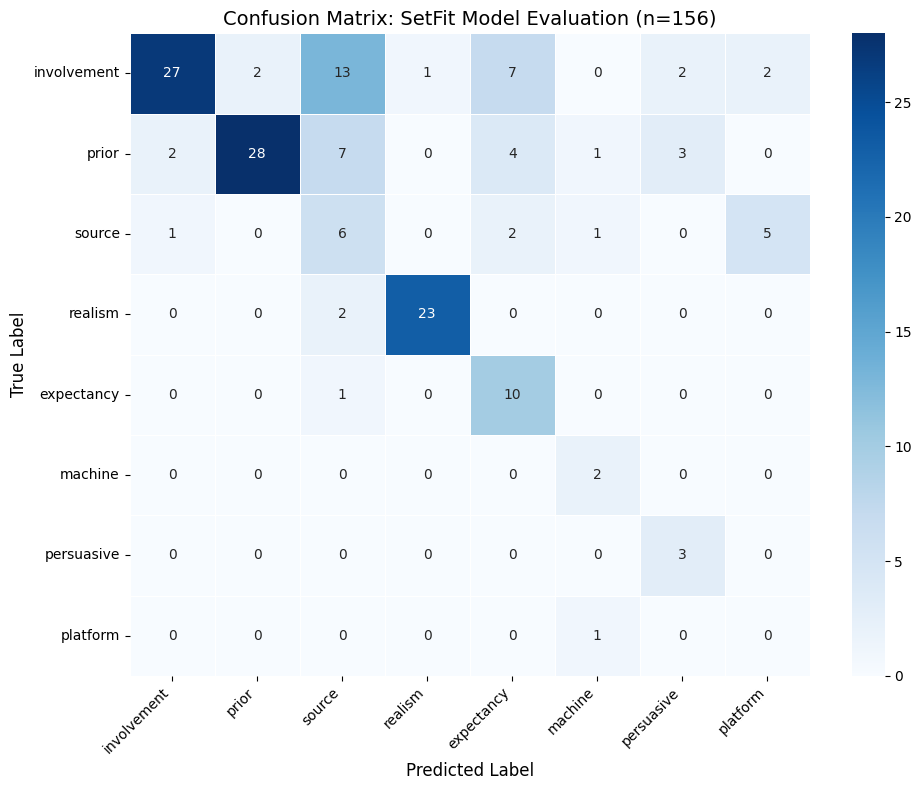

Confusion matrix saved!


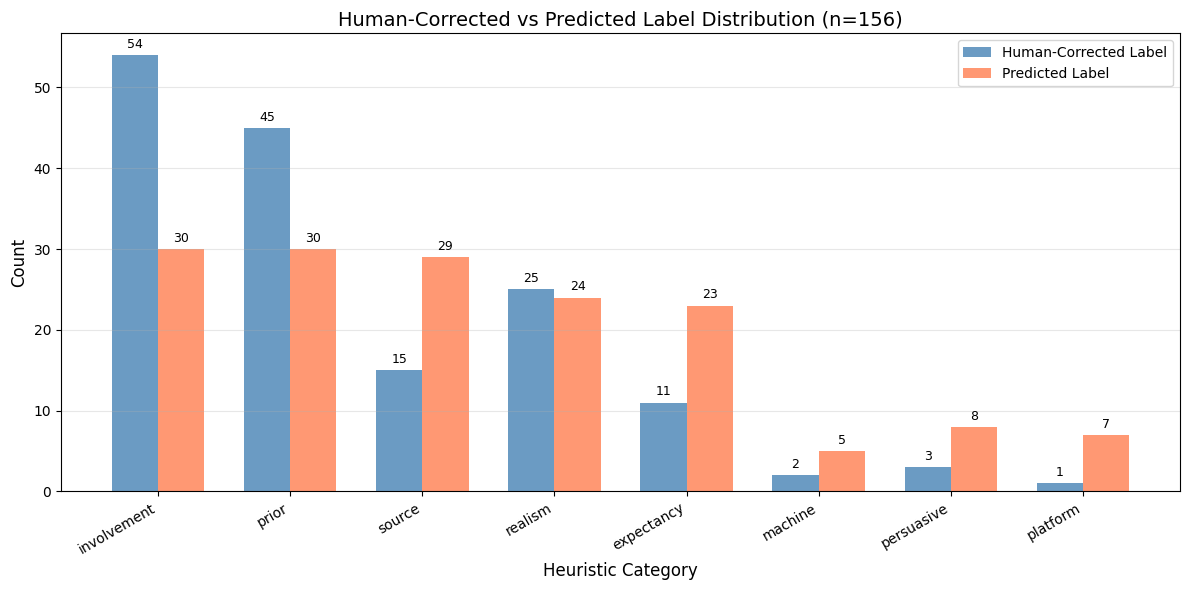

True vs predicted saved!


In [61]:
## 21. Visualization - Model Evaluation

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

labels_order = ['involvement', 'prior', 'source', 'realism', 'expectancy', 'machine', 'persuasive', 'platform']

# === Figure 1: Confusion Matrix ===
cm = confusion_matrix(
    df_check['final_label'].str.lower().str.strip().str.replace('invovement', 'involvement'),
    df_check['predicted_label'],
    labels=labels_order
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order,
    linewidths=0.5
)
plt.title('Confusion Matrix: SetFit Model Evaluation (n=156)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/Users/wangyunshao/Desktop/historical_heuristics/data/confusion_matrix.png', dpi=300)
plt.show()
print("Confusion matrix saved!")

# === Figure 2: True vs Predicted Label Distribution (n=156) ===
true_labels = df_check['final_label'].str.lower().str.strip().str.replace('invovement', 'involvement')
pred_labels = df_check['predicted_label'].str.lower().str.strip()

true_counts = true_labels.value_counts().reindex(labels_order, fill_value=0)
pred_counts = pred_labels.value_counts().reindex(labels_order, fill_value=0)

x = np.arange(len(labels_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, true_counts, width, label='Human-Corrected Label', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, pred_counts, width, label='Predicted Label', color='coral', alpha=0.8)

# Add numbers on top of bars
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Heuristic Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Human-Corrected vs Predicted Label Distribution (n=156)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels_order, rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/wangyunshao/Desktop/historical_heuristics/data/true_vs_predicted.png', dpi=300)
plt.show()
print("True vs predicted saved!")

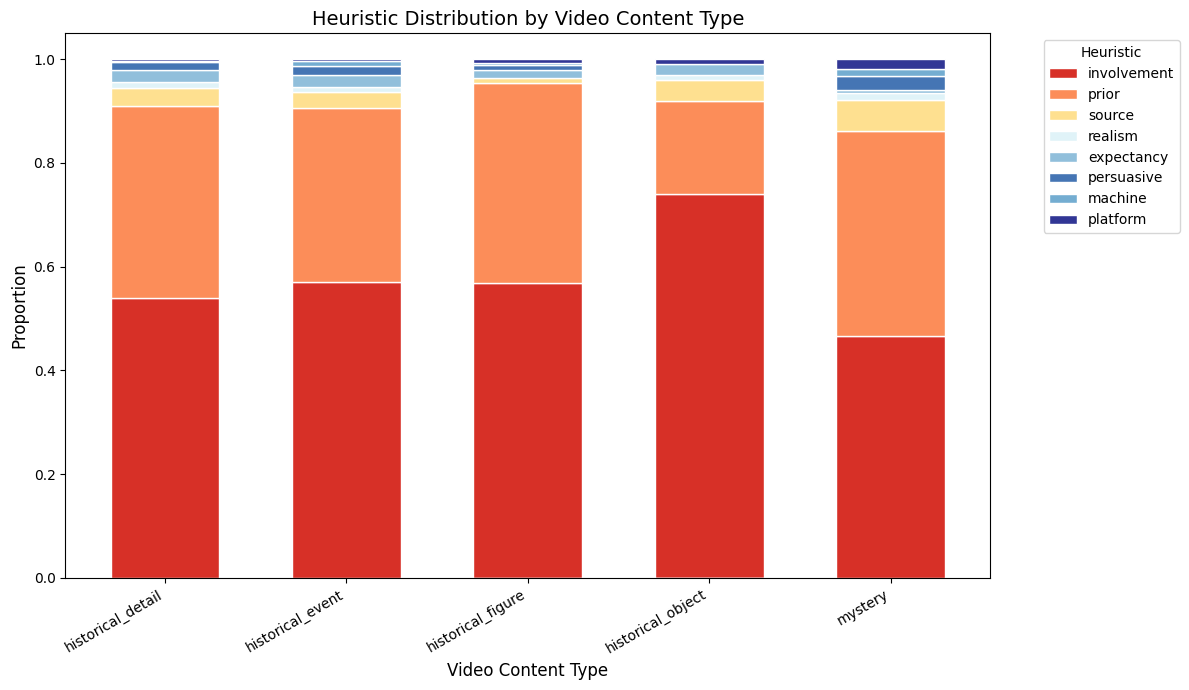

Saved!


In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine annotated + classified data
df_annotated_full = df_train[['content_type', 'label']].copy()
df_annotated_full = df_annotated_full.rename(columns={'label': 'heuristic'})

df_classified_full = df_final_mpnet[['content_type', 'predicted_label']].copy()
df_classified_full = df_classified_full.rename(columns={'predicted_label': 'heuristic'})

df_all = pd.concat([df_annotated_full, df_classified_full], ignore_index=True)

heuristic_order = ['involvement', 'prior', 'source', 'realism', 'expectancy', 'persuasive', 'machine', 'platform']
content_order = ['historical_detail', 'historical_event', 'historical_figure', 'historical_object', 'mystery']

# Column-normalized crosstab
ct = pd.crosstab(df_all['heuristic'], df_all['content_type'], normalize='columns')
ct = ct.reindex(index=heuristic_order, columns=content_order)

colors = ['#d73027','#fc8d59','#fee090','#e0f3f8','#91bfdb','#4575b4','#74add1','#313695']

ct.T.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    color=colors,
    width=0.6,
    edgecolor='white'
)

plt.title('Heuristic Distribution by Video Content Type', fontsize=14)
plt.xlabel('Video Content Type', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Heuristic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/Users/wangyunshao/Desktop/historical_heuristics/data/heuristic_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved!")

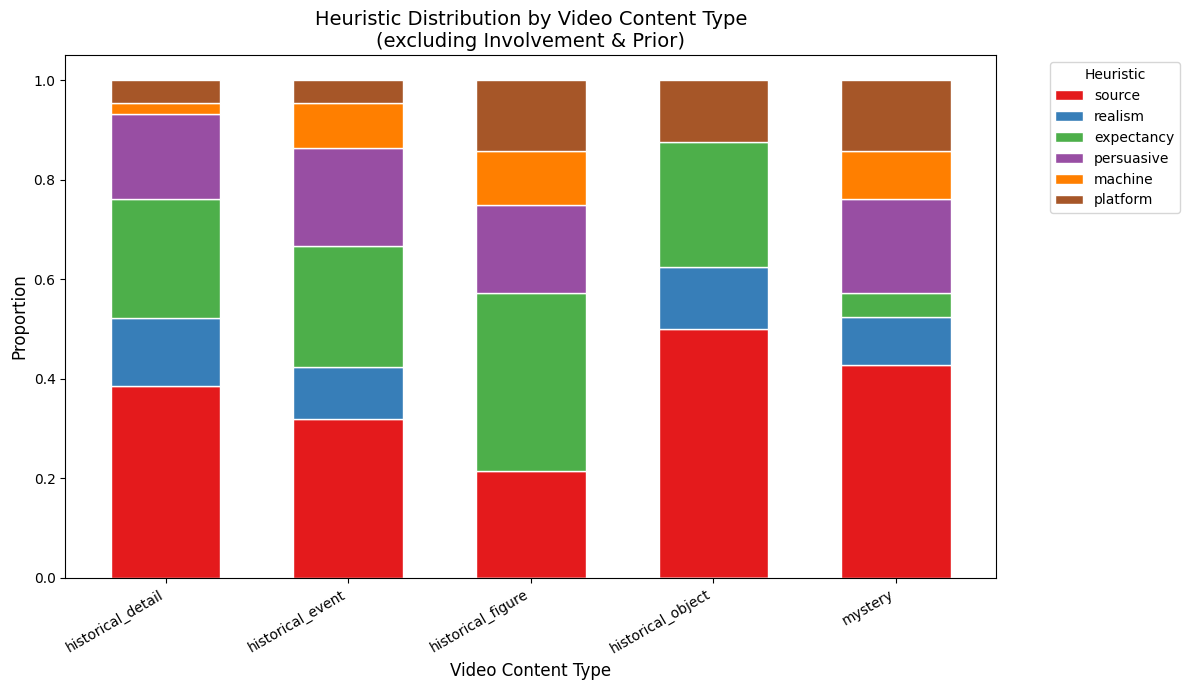

Saved!


In [57]:
heuristic_order_no_inv_prior = ['source', 'realism', 'expectancy', 'persuasive', 'machine', 'platform']

colors_contrast = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

ct_no_inv_prior = pd.crosstab(
    df_all[~df_all['heuristic'].isin(['involvement', 'prior'])]['heuristic'],
    df_all[~df_all['heuristic'].isin(['involvement', 'prior'])]['content_type'],
    normalize='columns'
)
ct_no_inv_prior = ct_no_inv_prior.reindex(index=heuristic_order_no_inv_prior, columns=content_order)

ct_no_inv_prior.T.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    color=colors_contrast,
    width=0.6,
    edgecolor='white'
)

plt.title('Heuristic Distribution by Video Content Type\n(excluding Involvement & Prior)', fontsize=14)
plt.xlabel('Video Content Type', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Heuristic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/Users/wangyunshao/Desktop/historical_heuristics/data/heuristic_stacked_bar_core.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved!")